In [1]:
%%time
import struct
import numpy as np
import os

#filename = "test.bin"
#filename = "pedro_lsst_mock_z_lt_0_2.bin"
#filename = "photoz_lsst_large_mock_z_lt_0_2.bin"
#filename = "photoz_lsst_large_mock_z_lt_0_5.bin"
filename = "photoz_lsst_large_BPZ_mock_z_lt_0_5.bin"
#filename = "photoz_lsst_large_FZ_mock_z_lt_0_5.bin"


binario = open(filename,"rb")
print("Reading file: %s" % (filename))

N = struct.unpack('<I',binario.read(4))[0]
print(N)

galaxy_id = []
halo_id = []
ra = [] 
dec = [] 
redshift = [] 
mag_r_lsst = [] 
mag_g_lsst = [] 
#mag_r_sdss = []
stellar_mass = [] 
halo_mass = []
position_x = []
position_y = []
position_z = []
is_central = [] 

###### new for photo ######33
photoz_mean= []
photoz_mode= []
photoz_odds= []

mag_r_photoz= []
mag_g_photoz= []
mag_err_r_photoz= []
mag_err_g_photoz= []    


#############################

for i in range(N):
  galaxy_id.append(struct.unpack('<q', binario.read(8))[0])
  halo_id.append(struct.unpack('<q', binario.read(8))[0])
  ra.append(struct.unpack('<f', binario.read(4))[0]) 
  dec.append(struct.unpack('<f', binario.read(4))[0]) 
  redshift.append(struct.unpack('<f', binario.read(4))[0]) 
  mag_r_lsst.append(struct.unpack('<f', binario.read(4))[0])
  mag_g_lsst.append(struct.unpack('<f', binario.read(4))[0])    
  #mag_r_sdss.append(struct.unpack('<f', binario.read(4))[0])
  halo_mass.append(struct.unpack('<f', binario.read(4))[0])
  stellar_mass.append(struct.unpack('<f', binario.read(4))[0])
    
  is_central.append(struct.unpack('<I',binario.read(4))[0]) 
  position_x.append(struct.unpack('<f', binario.read(4))[0])
  position_y.append(struct.unpack('<f', binario.read(4))[0])
  position_z.append(struct.unpack('<f', binario.read(4))[0])
    
  photoz_mean.append(struct.unpack('<f', binario.read(4))[0])
  photoz_mode.append(struct.unpack('<f', binario.read(4))[0])    
  photoz_odds.append(struct.unpack('<f', binario.read(4))[0])

  mag_r_photoz.append(struct.unpack('<f', binario.read(4))[0])
  mag_g_photoz.append(struct.unpack('<f', binario.read(4))[0])
  mag_err_r_photoz.append(struct.unpack('<f', binario.read(4))[0])
  mag_err_g_photoz.append(struct.unpack('<f', binario.read(4))[0])    
    
binario.close()

Reading file: photoz_lsst_large_BPZ_mock_z_lt_0_5.bin
19154934
CPU times: user 1min 1s, sys: 6.58 s, total: 1min 8s
Wall time: 1min 10s


In [2]:
print(len(galaxy_id))
print(len(ra))

19154934
19154934


In [3]:
len(np.unique(halo_id))

17731651

In [4]:
import random
import matplotlib.pyplot as plt

(19154,)


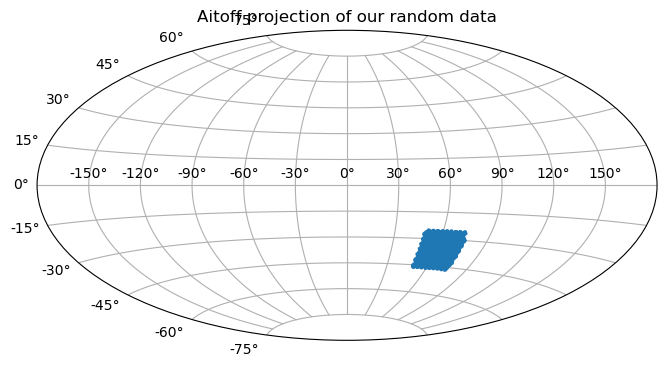

In [5]:
ra_rad = np.array(ra)*np.pi/180.
dec_rad = np.array(dec)*np.pi/180.

#seleccion de centros aleatoriamente
k= int(ra_rad.shape[0]/1000)
indices = np.random.randint(0,ra_rad.shape[0],k)
sampled_ra = ra_rad[indices]
sampled_dec = dec_rad[indices]
print(np.shape(sampled_ra))

plt.figure(figsize=(8,4.2))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff projection of our random data")
plt.grid(True)
plt.plot(sampled_ra, sampled_dec, '.', markersize=2, alpha=0.3)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()

In [6]:
k= int(ra_rad.shape[0]/100)
print(k)
indices = np.random.randint(0,ra_rad.shape[0],k)
print(indices)
sampled_ra = ra_rad[indices]
print(np.shape(sampled_ra))

191549
[ 7717732   243312  2839464 ... 10332936  1465867  7314257]
(191549,)


# Redshift Dsitribution

Text(0.5, 0, 'Refshift')

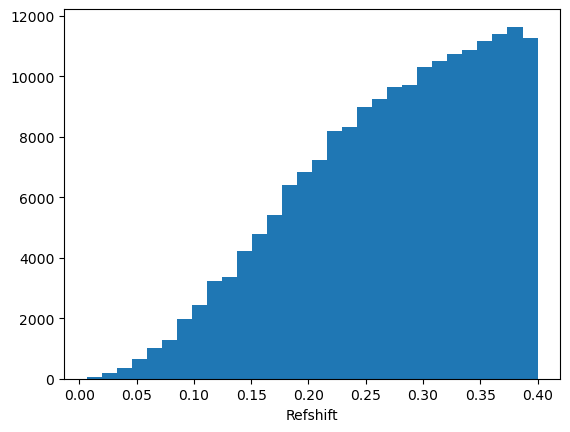

In [7]:
z=np.array(redshift)
plt.hist(z[indices],30)
plt.xlabel('Refshift')

# Mag_r_sdss Dsitribution

Text(0.5, 0, 'mag_r')

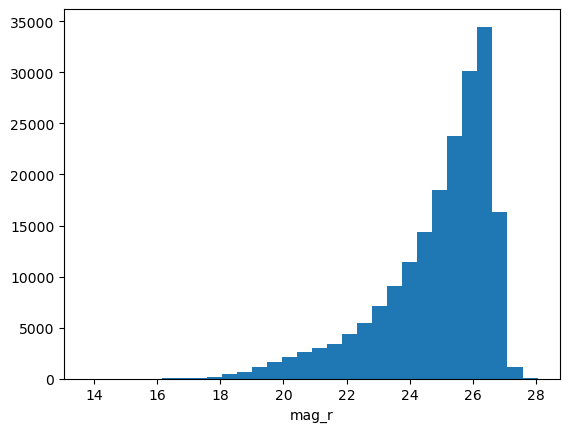

In [8]:
mag_r=np.array(mag_r_lsst)
#mag_r=np.array(mag_r_sdss)
plt.hist(mag_r[indices],30)
plt.xlabel('mag_r')

Text(0.5, 0, 'mag_r')

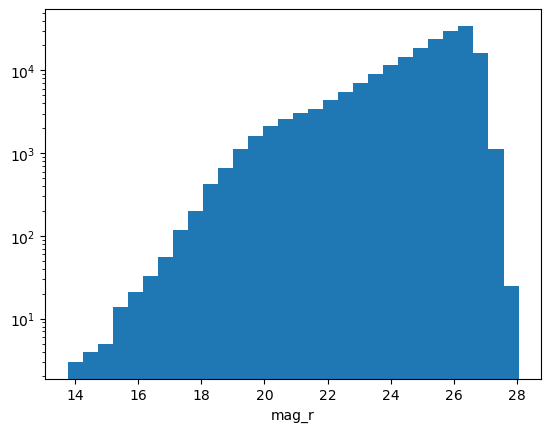

In [9]:
mag_r=np.array(mag_r_lsst)
plt.hist(mag_r[indices],30)
plt.yscale('log')
plt.xlabel('mag_r')

In [10]:
#-----------------------------------------------
#-------  Write file mag < 21. -----------------
#-----------------------------------------------

#Arrays--------
ra = np.array(ra)
dec = np.array(dec)
z=np.array(redshift)
mr_lsst=np.array(mag_r_lsst)

mg_lsst=np.array(mag_g_lsst)

idgal=np.array(galaxy_id)
#mr_sdss=np.array(mag_r_sdss)
halo_id=np.array(halo_id)
lhalo_mass=np.log10(np.array(halo_mass))
lstellar_mass=np.log10(np.array(stellar_mass))

position_x=np.array(position_x)
position_y=np.array(position_y)
position_z=np.array(position_z)

is_central=np.array(is_central) 

photoz_mean=np.array(photoz_mean)
photoz_mode=np.array(photoz_mode)
photoz_odds=np.array(photoz_odds)

mag_r_photoz=np.array(mag_r_photoz)
mag_g_photoz=np.array(mag_g_photoz)
mag_err_r_photoz=np.array(mag_err_r_photoz)
mag_err_g_photoz=np.array(mag_err_g_photoz)    

# cut apparent magnitude
ii = np.where(mr_lsst<=21.)
print(len(mr_lsst[ii]))


tofile = [idgal[ii], ra[ii], dec[ii], z[ii], mr_lsst[ii], mg_lsst[ii],
          halo_id[ii], lhalo_mass[ii], lstellar_mass[ii], position_x[ii], position_y[ii], position_z[ii],is_central[ii],
         photoz_mean[ii] ,photoz_mode[ii] ,photoz_odds[ii] ,mag_r_photoz[ii] ,mag_g_photoz[ii] ,mag_err_r_photoz[ii] ,mag_err_g_photoz[ii]]
print(np.shape(tofile))

outfil = 'mock_21_large_BPZ_z05_cosmoDC2.dat'
#outfil = 'mock_21_large_FZ_z05_cosmoDC2.dat'

with open(outfil, 'w') as outf:
    outf.write('#galid, ra, dec, z, mr_lsst, mg_lsst, halo_id, loghalo_mass, logstellar_mass, position_x, position_y, position_z, is_central, photoz_mean, photoz_mode, photoz_odds, mag_r_photoz ,mag_g_photoz, mag_err_r_photoz, mag_err_g_photoz \n')
    np.savetxt(outf,np.column_stack(tofile),
               fmt=('%.14d %.5f %.5f %.5f %.5f %.5f %.14d %.5f %.5f %.5f %.5f %.5f %.5d %.5f %.5f %.5f %.5f %.5f %.5f %.5f'), delimiter="  ")
outf.closed
print('Output: {}'.format(outfil))

939345
(20, 939345)
Output: mock_21_large_BPZ_z05_cosmoDC2.dat
